In [1]:
import transformers
print(transformers.__version__)


/Users/shoaib/Desktop/University/5th Semester/NLP/Project/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


4.57.3


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, roc_auc_score, top_k_accuracy_score
)

import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)


2025-11-28 21:53:09.560355: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
df = pd.read_csv("data/news_sentiment_final.csv")

df["sentiment"] = df["sentiment"].astype(int)
df["clean_content"] = df["clean_content"].astype(str)

# map 1–5 → 0–4
df["label"] = df["sentiment"] - 1

texts = df["clean_content"].tolist()
labels = df["label"].tolist()

num_classes = 5

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

len(train_texts), len(test_texts)


(2837, 710)

In [4]:
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

max_length = 256

train_ds = Dataset.from_dict({"text": train_texts, "label": train_labels})
test_ds  = Dataset.from_dict({"text": test_texts,  "label": test_labels})

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_test  = test_ds.map(tokenize_function, batched=True)

# keep only model inputs + label
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_test  = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_test.set_format("torch")


Map: 100%|██████████| 710/710 [00:00<00:00, 723.52 examples/s]


In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_classes
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)

    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro"
    )

    return {
        "accuracy": acc,
        "precision_macro": prec,
        "recall_macro": rec,
        "f1_macro": f1,
    }


In [8]:
from transformers import TrainingArguments, Trainer

batch_size = 8  # adjust if needed

training_args = TrainingArguments(
    output_dir="./distilbert_news_sentiment",
    eval_strategy="epoch",          # <-- IMPORTANT: this is what your version supports
    save_strategy="no",             # don't spam checkpoints
    num_train_epochs=3,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics
)


In [9]:
trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.562000,0.522714,0.816901,0.487932,0.462854,0.463749
2,0.231100,0.433267,0.878873,0.664145,0.629023,0.643159
3,0.159500,0.376155,0.901408,0.713029,0.647266,0.670606


/Users/shoaib/Desktop/University/5th Semester/NLP/Project/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shoaib/Desktop/University/5th Semester/NLP/Project/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/shoaib/Desktop/University/5th Semester/NLP/Project/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

TrainOutput(global_step=1065, training_loss=0.413835029422957, metrics={'train_runtime': 3741.6058, 'train_samples_per_second': 2.275, 'train_steps_per_second': 0.285, 'total_flos': 563745174151680.0, 'train_loss': 0.413835029422957, 'epoch': 3.0})

In [10]:
pred_output = trainer.predict(tokenized_test)

logits = pred_output.predictions
y_true = np.array(test_labels)
y_proba = torch.softmax(torch.tensor(logits), dim=1).numpy()
y_pred = np.argmax(y_proba, axis=1)


/Users/shoaib/Desktop/University/5th Semester/NLP/Project/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [11]:
num_classes = 5
y_true_oh = np.eye(num_classes)[y_true]

accuracy_tr = accuracy_score(y_true, y_pred)
precision_tr, recall_tr, f1_tr, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro"
)
auc_tr = roc_auc_score(
    y_true_oh, y_proba, multi_class="ovr", average="macro"
)
top3_tr = top_k_accuracy_score(y_true, y_proba, k=3)
cm_tr = confusion_matrix(y_true, y_pred)

print("=== DistilBERT Transformer Evaluation Metrics ===")
print(f"Accuracy (Exact Match): {accuracy_tr:.4f}")
print(f"Precision (Macro):      {precision_tr:.4f}")
print(f"Recall (Macro):         {recall_tr:.4f}")
print(f"F1-Score (Macro):       {f1_tr:.4f}")
print(f"AUC (Macro OVR):        {auc_tr:.4f}")
print(f"Top-3 Accuracy:         {top3_tr:.4f}")
print("\nConfusion Matrix:\n", cm_tr)


=== DistilBERT Transformer Evaluation Metrics ===
Accuracy (Exact Match): 0.9014
Precision (Macro):      0.7130
Recall (Macro):         0.6473
F1-Score (Macro):       0.6706
AUC (Macro OVR):        0.9600
Top-3 Accuracy:         0.9958

Confusion Matrix:
 [[264   7   0   5   0]
 [  6  77   0  17   0]
 [  0   5   0   0   0]
 [  6  10   0 282   1]
 [  6   0   0   7  17]]


/Users/shoaib/Desktop/University/5th Semester/NLP/Project/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


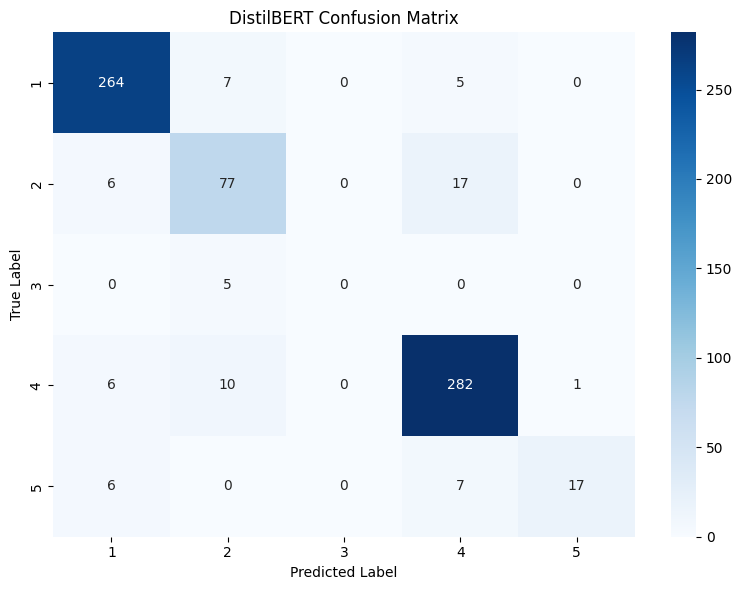

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class labels (1–5 sentiment scores)
class_names = ["1", "2", "3", "4", "5"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_tr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("DistilBERT Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [18]:
import pandas as pd

# Create a dictionary for DistilBERT metrics
bert_metrics_dict = {
    "Metric": [
        "Accuracy (Exact Match)",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-Score (Macro)",
        "AUC (Macro OVR)",
        "Top-3 Accuracy"
    ],
    "Value": [
        accuracy_tr,
        precision_tr,
        recall_tr,
        f1_tr,
        auc_tr,
        top3_tr
    ]
}

# Convert to DataFrame
bert_metrics_df = pd.DataFrame(bert_metrics_dict)

# Save to CSV
bert_metrics_df.to_csv("distilbert_evaluation_metrics.csv", index=False)

bert_metrics_df


,Metric,Value
0,Accuracy (Exact Match),0.901408
1,Precision (Macro),0.713029
2,Recall (Macro),0.647266
3,F1-Score (Macro),0.670606
4,AUC (Macro OVR),0.959976
5,Top-3 Accuracy,0.995775


In [12]:
trainer.save_model("./distilbert_news_sentiment_final")
tokenizer.save_pretrained("./distilbert_news_sentiment_final")


('./distilbert_news_sentiment_final/tokenizer_config.json',
 './distilbert_news_sentiment_final/special_tokens_map.json',
 './distilbert_news_sentiment_final/vocab.txt',
 './distilbert_news_sentiment_final/added_tokens.json',
 './distilbert_news_sentiment_final/tokenizer.json')

In [13]:
logs = trainer.state.log_history

train_epochs = []
train_loss = []

eval_epochs = []
eval_loss = []
eval_acc = []

for entry in logs:
    # Training step log (has "loss" + "epoch", but no eval_loss)
    if "loss" in entry and "epoch" in entry and "eval_loss" not in entry:
        train_epochs.append(entry["epoch"])
        train_loss.append(entry["loss"])

    # Evaluation log (has "eval_loss", and maybe "eval_accuracy")
    if "eval_loss" in entry:
        eval_epochs.append(entry["epoch"])
        eval_loss.append(entry["eval_loss"])
        if "eval_accuracy" in entry:
            eval_acc.append(entry["eval_accuracy"])


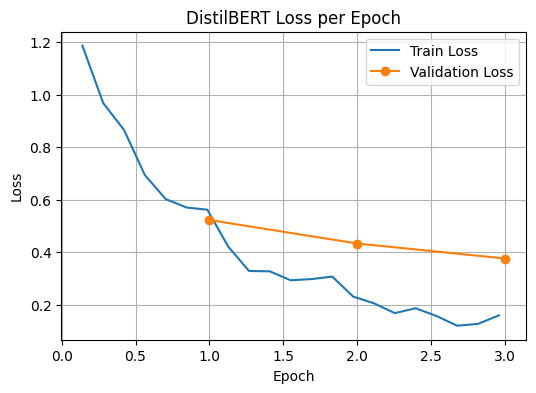

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_epochs, train_loss, label="Train Loss")
plt.plot(eval_epochs,  eval_loss,  marker="o", label="Validation Loss")
plt.title("DistilBERT Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()


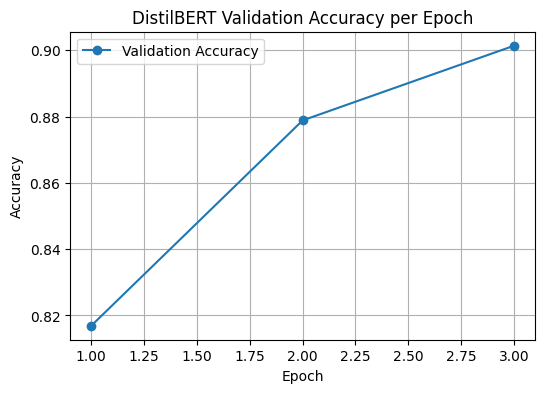

In [15]:
if len(eval_acc) > 0:
    plt.figure(figsize=(6,4))
    plt.plot(eval_epochs, eval_acc, marker="o", label="Validation Accuracy")
    plt.title("DistilBERT Validation Accuracy per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No eval_accuracy found in logs. Check compute_metrics.")
